# 03. Statistical Driver Analysis

The EDA suggested branded intent and device matter most. This notebook makes
those claims precise with two weighted least squares models, one per target,
plus direct hypothesis tests.

Two methodological choices worth calling out:

1. **Weighting.** A CTR computed from 40 impressions is far noisier than one
   computed from 4,000, so each observation is weighted by its denominator
   (impressions for the CTR model, clicks for the CVR model).
2. **Robust errors.** Standard errors are HC3 heteroskedasticity robust, so
   the p-values do not depend on the constant-variance assumption the raw
   rates clearly violate.

Coefficients are in percentage points and read directly: "switching from
desktop to mobile is worth about X points of CTR, all else equal".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import data_prep, eda, stats_analysis, modeling
from src.plotting import apply_style

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
df = eda.load_processed()
ctr_model, cvr_model = stats_analysis.fit_models(df)
print(f"CTR model R2: {ctr_model.rsquared:.3f}")
print(f"CVR model R2: {cvr_model.rsquared:.3f}")

CTR model R2: 0.599
CVR model R2: 0.331


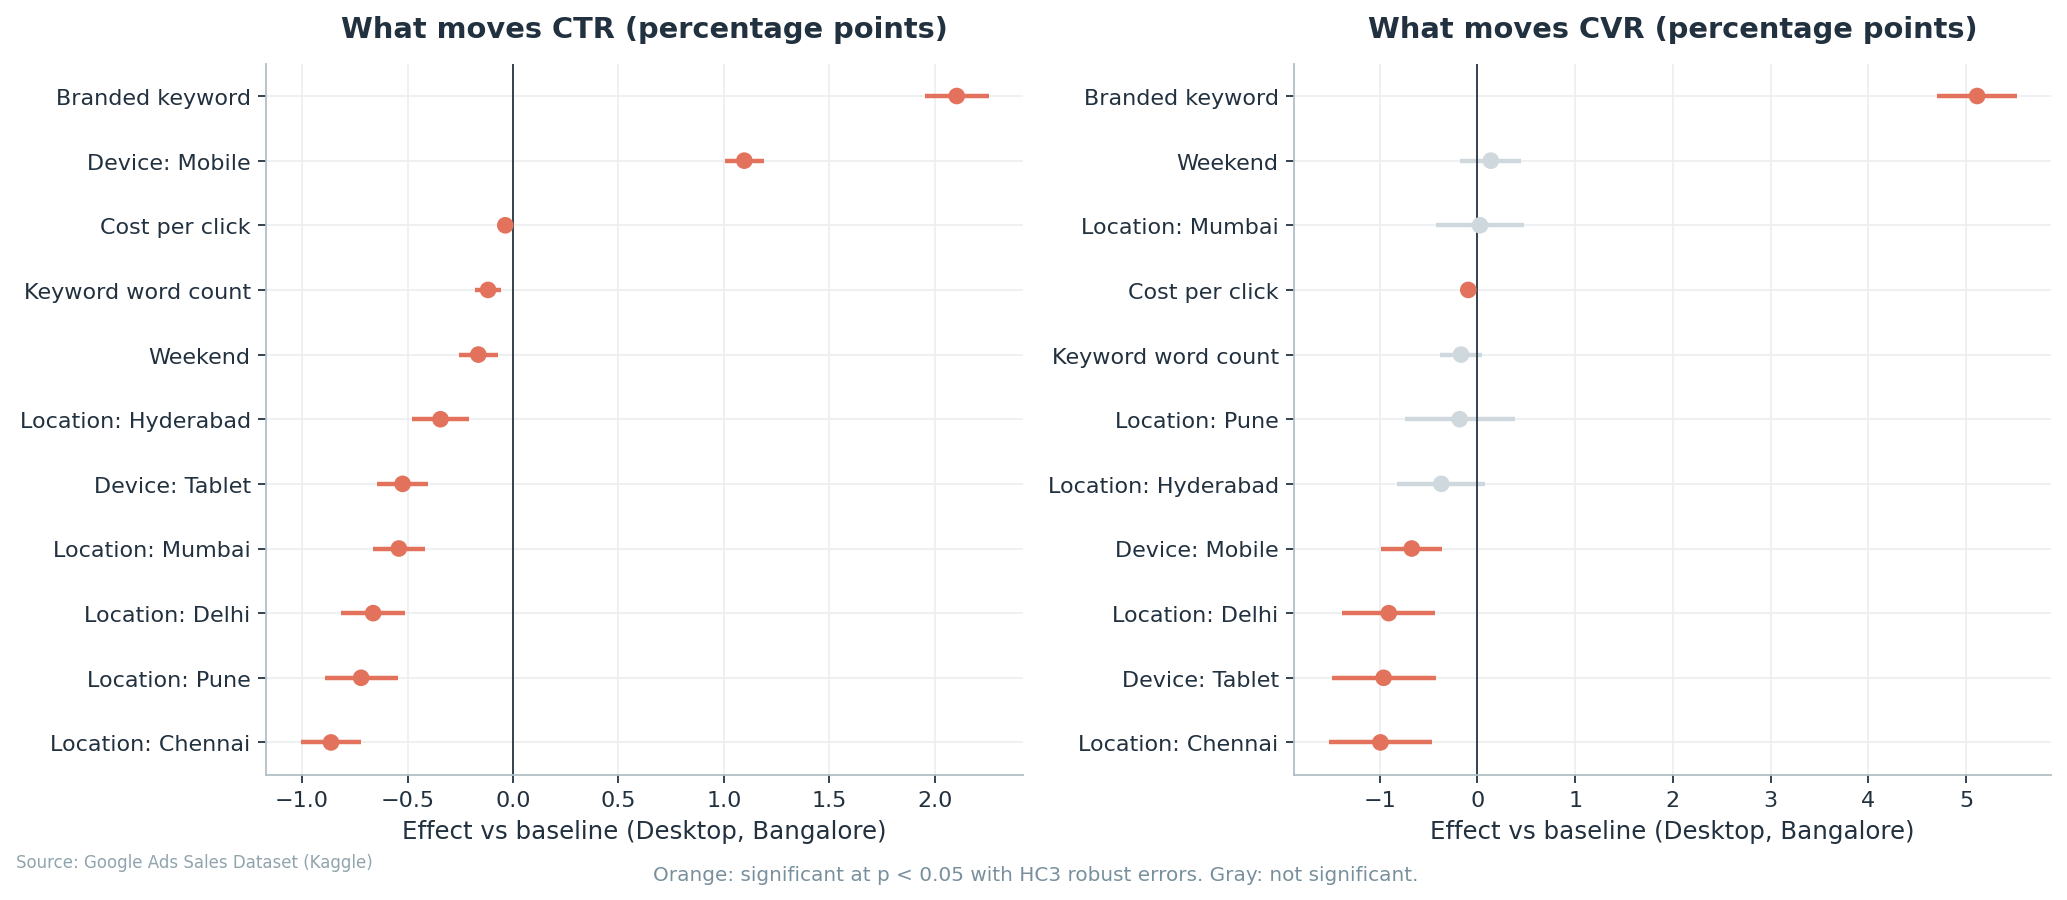

In [3]:
stats_analysis.fig_coefficients(ctr_model, cvr_model)
display(Image("reports/figures/09_regression_coefficients.png"))

Reading the chart: orange intervals exclude zero at the 5 percent level.
Branded intent dominates both models. Device is the second CTR driver and
flips sign for CVR, the classic browse-on-mobile, buy-on-desktop pattern.
Cost per click is flat for CTR once intent is controlled, meaning expensive
clicks are not better clicks.

Full regression tables below, also saved under `reports/tables/`.

In [4]:
ctr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                ctr_pct   R-squared:                       0.599
Model:                            WLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     213.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:35:10   Log-Likelihood:                -5366.0
No. Observations:                3428   AIC:                         1.076e+04
Df Residuals:                    3416   BIC:                         1.083e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     4.6806      0.162     28.835      0.000       4.362       4.999
C(device, Treatment('Desktop'))[T.Mobile]     1.0970      0.047     23.144      0.000       1.004       1.190
C(device, Treatment('Desktop'))[T.Tablet]    -0.5235      0.061     -8.553      0.000      -0.644      -0.404
C(location)[T.Chennai]                       -0.8631      0.073    -11.747      0.000      -1.007      -0.719
C(location)[T.Delhi]                         -0.6633      0.077     -8.598      0.000      -0.814      -0.512
C(location)[T.Hyderabad]                     -0.3438      0.068     -5.029      0.000      -0.478      -0.210
C(location)[T.Mumbai]                        -0.5411      0.063     -8.530      0.000      -0.665      -0.417
C(location)[T.Pune]                          -0.7202      0.088     -8.174      0.000      -0.893      -0.548
is_branded                                    2.1043      0.078     27.121      0.000       1.952       2.256
keyword_word_count                           -0.1182      0.032     -3.711      0.000      -0.181      -0.056
is_weekend                                   -0.1644      0.047     -3.470      0.001      -0.257      -0.072
cpc                                          -0.0366      0.007     -5.054      0.000      -0.051      -0.022
==============================================================================
Omnibus:                      344.071   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1126.804
Skew:                          -0.499   Prob(JB):                    2.08e-245
Kurtosis:                       5.626   Cond. No.                         104.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [5]:
cvr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                cvr_pct   R-squared:                       0.331
Model:                            WLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     101.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          1.60e-200
Time:                        06:35:10   Log-Likelihood:                -9899.4
No. Observations:                3358   AIC:                         1.982e+04
Df Residuals:                    3346   BIC:                         1.990e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     8.2070      0.501     16.396      0.000       7.226       9.188
C(device, Treatment('Desktop'))[T.Mobile]    -0.6717      0.158     -4.242      0.000      -0.982      -0.361
C(device, Treatment('Desktop'))[T.Tablet]    -0.9599      0.272     -3.530      0.000      -1.493      -0.427
C(location)[T.Chennai]                       -0.9923      0.271     -3.667      0.000      -1.523      -0.462
C(location)[T.Delhi]                         -0.9073      0.242     -3.753      0.000      -1.381      -0.433
C(location)[T.Hyderabad]                     -0.3695      0.229     -1.611      0.107      -0.819       0.080
C(location)[T.Mumbai]                         0.0263      0.231      0.114      0.909      -0.426       0.478
C(location)[T.Pune]                          -0.1819      0.288     -0.632      0.528      -0.746       0.382
is_branded                                    5.1133      0.207     24.684      0.000       4.707       5.519
keyword_word_count                           -0.1678      0.109     -1.539      0.124      -0.381       0.046
is_weekend                                    0.1375      0.160      0.861      0.389      -0.176       0.451
cpc                                          -0.0933      0.024     -3.960      0.000      -0.139      -0.047
==============================================================================
Omnibus:                      187.782   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              248.692
Skew:                           0.525   Prob(JB):                     9.93e-55
Kurtosis:                       3.821   Cond. No.                         100.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## Hypothesis tests

Three direct comparisons with the Mann-Whitney U test, chosen because the
rate distributions are right skewed:

In [6]:
tests = stats_analysis.hypothesis_tests(df)
tests

,test,statistic,p_value,group_a_mean,group_b_mean
0,Mobile CTR > Desktop CTR (Mann-Whitney U),"1,611,939.5000",0.0000,0.0487,0.0377
1,Branded CVR > Non-branded CVR (Mann-Whitney U),"1,512,842.5000",0.0000,0.1071,0.0551
2,Weekend CTR differs from weekday CTR (Mann-Whi...,"1,186,758.5000",0.0027,0.0421,0.0439


All three headline differences hold up: mobile CTR exceeds desktop CTR,
branded CVR exceeds non-branded CVR, and the weekend dip in CTR is small but
real. Continue with `04_predictive_modeling.ipynb`.